In [1]:
from langchain.chains import RetrievalQA
from langchain.document_loaders import TextLoader
from langchain.vectorstores import FAISS
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.llms import Ollama

# 1. 데이터 로드
loader = TextLoader("./dataset/history.txt", encoding='UTF8')  # 텍스트 파일 로드
documents = loader.load()  # 문서 로드

In [ ]:
# 2. 벡터 임베딩 생성 (Hugging Face 사용)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2") # 에러가 자주 발생하는 모델
vectorstore = FAISS.from_documents(documents, embeddings)

C:\Users\humna-20\AppData\Local\Temp\ipykernel_33532\3515032426.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
c:\NEWTEST\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c:\NEWTEST\myenv\lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\humna-20\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [3]:
# 3. 검색기(retriever) 설정
retriever = vectorstore.as_retriever()

In [ ]:
# 4. Ollama Gemma3 모델 초기화
llm = Ollama(model="gemma3", base_url="http://localhost:11434")  # Ollama 서버 설정 / 포트를 기억해두기(:11434)

C:\Users\humna-20\AppData\Local\Temp\ipykernel_33532\3062886086.py:2: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  llm = Ollama(model="gemma3", base_url="http://localhost:11434")  # Ollama 서버 설정


In [5]:
# 5. RAG 체인 구성
qa_chain = RetrievalQA.from_chain_type(llm=llm, retriever=retriever)

In [ ]:
# 6. 질문 실행
query = "고조선이 언제 설립되었는지 알려줘."
response = qa_chain.run(query)
print("Response:", response)

C:\Users\humna-20\AppData\Local\Temp\ipykernel_33532\434419744.py:3: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = qa_chain.run(query)


Response: 고조선은 기원전 2333년에 단군왕검에 의해 세워졌습니다.


In [7]:
import json
from langchain_community.chat_models import ChatOllama
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

json_schema = {
    "title" : "Person",
    "description": "Identifying information about a person.",
    "type": "object",
    "properties": {
        "name" : {"title": "Name", "description": "The person's name", "type": "string"},
        "age": {"title": "Age", "description": "The person's age", "type": "integer"},
        "occupation": {
            "title": "Occupation",
            "description": "The person's Occupation",
            "type": "string",
        },
    },
    "required": ["name", "age"],
}

llm = ChatOllama(model="gemma3")

messages = [
    HumanMessage(
        content = "Please tell me about a person using the following JSON schema:"
    ),
    HumanMessage(content="{dumps}"),
    HumanMessage(
        content="""Now, considering the schema, please describe following person:
        Her name is Eun-Chae Lee, she is 25 years old, and she is a software engineer.
        """
    ),
]

prompt = ChatPromptTemplate.from_messages(
    messages
)

dumps = json.dumps(json_schema, indent=2)

chain = (
    prompt | llm | StrOutputParser()
)

chain.invoke({"dumps": dumps})

C:\Users\humna-20\AppData\Local\Temp\ipykernel_33532\19771246.py:23: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  llm = ChatOllama(model="gemma3")


'Okay, let\'s craft a person based on the following JSON schema and the given details.  Since you didn\'t provide a JSON schema, I\'ll create a reasonable one to work with.  I\'ll then populate it with the information you provided.\n\n**JSON Schema (Example - I\'m creating this for context)**\n\n```json\n{\n  "type": "object",\n  "properties": {\n    "name": {\n      "type": "string",\n      "description": "The person\'s full name."\n    },\n    "age": {\n      "type": "integer",\n      "description": "The person\'s age in years.",\n      "minimum": 0\n    },\n    "occupation": {\n      "type": "string",\n      "description": "The person\'s professional occupation."\n    },\n    "skills": {\n      "type": "array",\n      "description": "A list of skills the person possesses (optional)."\n    },\n    "location": {\n      "type": "string",\n      "description": "The person\'s location (optional)."\n    }\n  },\n  "required": [\n    "name",\n    "age",\n    "occupation"\n  ]\n}\n```\n\n**

In [ ]:
#%pip install gradio

  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/51.3 MB ? eta -:--:--
   - -------------------------------------- 2.4/51.3 MB 12.2 MB/s eta 0:00:05
   --- ------------------------------------ 4.7/51.3 MB 11.9 MB/s eta 0:00:04
   ----- ---------------------------------- 7.1/51.3 MB 12.1 MB/s eta 0:00:04
   ------- -------------------------------- 9.7/51.3 MB 11.8 MB/s eta 0:00:04
   --------- ------------------------------ 12.3/51.3 MB 11.9 MB/s eta 0:00:04
   ----------- ---------------------------- 14.7/51.3 MB 11.8 MB/s eta 0:00:04
   ------------- -------------------------- 17.3/51.3 MB 11.9 MB/s eta 0:00:03
   --------------- ------------------------ 19.9/51.3 MB 11.9 MB/s eta 0:00:03
   ----------------- ---------------------- 22.5/51.3 MB 11.9 MB/s eta 0:00:03
   ------------------- -------------------- 24.9/51.3 MB 11.8 MB/s eta 0:00:03
   --------------------- ------------------ 27.5/51.3 MB 11.8 MB/s eta 0:00:03
   

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import gradio as gr
import os

# 텍스트 파일 읽기
with open('./dataset/history.txt', 'r', encoding='utf-8') as file:
    text = file.read()
    
# 워드클라우드 설정 및 생성
wordcloud = WordCloud(
    font_path='malgun',  # 한글 폰트 설정 (맑은 고딕)
    background_color='white',
    width=800,
    height=600,
    max_words=200,
    max_font_size=100,
    min_font_size=10,
    random_state=42
).generate(text)

(np.float64(-0.5), np.float64(799.5), np.float64(599.5), np.float64(-0.5))

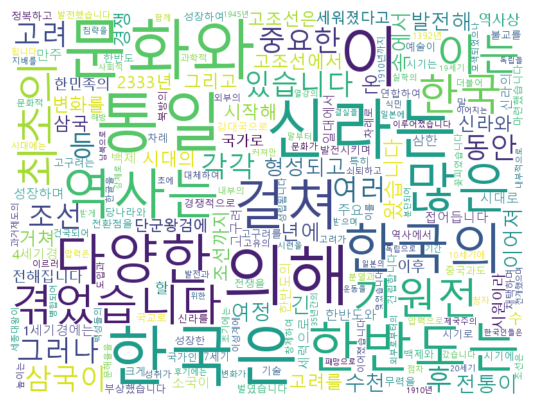

In [13]:
# 워드 클라우드 이미지 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

In [ ]:
# 워드 클라우드 생성함수
def generate_wordcloud(file_obj):
    try:
        # 파일이 없는 경우 처리
        if file_obj is None:
            return None

        # Gradio의 파일 객체에서 파일 경로 가져오기
        file_path = file_obj.name

        # 파일 읽기
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()

        # 워드클라우드 생성
        wordcloud = WordCloud(
            font_path='malgun',  # 한글 폰트 설정 (맑은 고딕)
            background_color='white',
            width=800,
            height=600,
            max_words=200,
            max_font_size=100,
            min_font_size=10,
            random_state=42
        ).generate(text)

        # matplotlib 그래프 초기화
        plt.clf()

        # 워드클라우드 이미지를 플롯
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.tight_layout()

        # 결과 이미지를 저장
        output_path = 'wordcloud.png'
        plt.savefig(output_path)
        plt.close()  # 메모리 누수 방지를 위해 figure 닫기
        return output_path

    except Exception as e:
        print(f"Error: {str(e)}")
        return None
    
# Gradio 인터페이스 생성
iface = gr.Interface(
    fn=generate_wordcloud,
    inputs=gr.File(label="Upload a .txt file"),
    outputs=gr.Image(type="filepath", label="Word Cloud")
)

# Gradio 페이지 실행
iface.launch(server_port=7861, share=True, server_name="0.0.0.0")
# share=True 외부에서 접근할 수 있게 함 (False라면 로컬만 가능)
# server_name="0.0.0.0"는 리눅스환경에서 필요

* Running on local URL:  http://0.0.0.0:7861
* Running on public URL: https://1aeb557e2a50c088ea.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio\flagged\dataset1.csv
Error: 'utf-8' codec can't decode byte 0xff in position 0: invalid start byte


In [15]:
iface.close()

Closing server running on port: 7861
